In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۶ — تکنیک‌های یادگیری تجمعی (Ensemble Learning Techniques)
## درس ۴: تکنیک‌های استکینگ (Stacking) و بلِندینگ (Blending)

**آموزش‌های یادگیری ماشین: ۳۷ فصل**  
**این فصل:** ۱۱ درس (درس ۱ تا درس ۱۱)

در این درس با **استکینگ** و **بلِندینگ** آشنا می‌شوید—دو راهبرد «متا-اِنسِمبل» که چند مدل پایهٔ ناهمگون را با یک **فرا-یادگیرنده (meta-learner)** ترکیب می‌کنند. ما هم مباحث نظری و ریاضی (به‌ویژه مسئلهٔ نشت اطلاعات/Leakage) را پوشش می‌دهیم و هم چند پیاده‌سازی عملی را با چندین دیتاست مختلف همین مخزن انجام می‌دهیم.

> **خروجی‌های کلیدی**
- تعریف دقیق استکینگ در برابر بلِندینگ و دانستن اینکه هرکدام چه زمانی مناسب‌اند.
- پیاده‌سازی صحیح استکینگ با **پیش‌بینی‌های خارج از فولد (Out-of-Fold / OOF)** برای جلوگیری از لیکیج.
- استفاده از `StackingClassifier` و `StackingRegressor` در `sklearn` و همچنین پیاده‌سازی استکینگ «از صفر».
- مقایسهٔ کارایی و کالیبراسیون روی **چند دیتاست طبقه‌بندی و رگرسیون**.
- یادگیری قواعد طراحی عملی: تنوع مدل‌ها، انتخاب متا-یادگیرنده، passthrough، و پروتکل ارزیابی.



### دیاگرام ۱ — Stacking (OOF meta-features)

```mermaid
flowchart TD
  A["Training data (X, y)"] --> B["Split into K folds"]
  B --> C["For each base model m_j and each fold k: train on K-1 folds"]
  C --> D["Predict on held-out fold k (OOF predictions)"]
  D --> E["Concatenate all OOF predictions -> Z (meta-features)"]
  E --> F["Train meta-learner g on (Z, y)"]
  F --> G["At test time: base models fit on full training set"]
  G --> H["Base predictions on X_test -> Z_test"]
  H --> I["Meta-learner predicts final output"]
```



## ۱. چرا استکینگ و بلِندینگ؟

بَگینگ و بوستینگ «خانواده‌های الگوریتمی» هستند که مکانیزم‌های نسبتاً ثابت دارند:

- **Bagging** با میانگین‌گیری (یا رأی‌گیری) روی مدل‌هایی که روی نمونه‌های بوت‌استرپ آموزش دیده‌اند، واریانس را کاهش می‌دهد.
- **Boosting** مدل‌ها را به‌صورت ترتیبی می‌سازد تا با تمرکز بر خطاها، بایاس را کاهش دهد.

اما **Stacking** و **Blending** متفاوت‌اند: آن‌ها **متا-اِنسِمبل** هستند که یاد می‌گیرند *چطور* مدل‌های پایهٔ دلخواه را ترکیب کنند. شما می‌توانید ترکیبی از موارد زیر داشته باشید:

- مدل‌های خطی + درختی + کرنلی + همسایه‌محور (kNN)،
- پایپ‌لاین‌های متفاوتِ مهندسی ویژگی و پیش‌پردازش،
- تنظیمات مختلف ابرپارامترها،
- حتی نمایش‌های متفاوت خروجی (مثلاً احتمال‌ها در برابر لاجیت‌ها).

ایدهٔ اصلی این است که از پیش‌بینی‌های مدل‌های پایه یک دیتاست سطح دوم بسازیم:

- مدل‌های پایه را $m_1,\dots,m_J$ در نظر بگیرید.
- برای هر نمونه $x_i$، **متا-ویژگی‌ها** را تعریف کنید:
  - رگرسیون: $z_i = [m_1(x_i),\dots,m_J(x_i)] \in \mathbb{R}^J$,
  - طبقه‌بندی (احتمال‌ها): $z_i = [p_1(y|x_i),\dots,p_J(y|x_i)]$ (به‌صورت تخت‌شده).

سپس یک **متا-یادگیرنده** $g$ خروجی نهایی را پیش‌بینی می‌کند:
$$
\hat{y}(x) = g(z(x)).
$$

### استکینگ در برابر بلِندینگ (مفهومی)
- **استکینگ:** متا-یادگیرنده روی پیش‌بینی‌های **OOF** (از طریق CV) آموزش می‌بیند. یعنی تمام دادهٔ آموزشی برای تولید متا-ویژگی‌ها استفاده می‌شود بدون نشت اطلاعات.
- **بلِندینگ:** متا-یادگیرنده روی پیش‌بینی‌های یک «مجموعهٔ نگه‌داشته‌شدهٔ Holdout» (blend set) آموزش می‌بیند. ساده‌تر و سریع‌تر است، اما از نظر استفادهٔ بهینه از داده ضعیف‌تر است.

در ادامه هر دو را پیاده‌سازی می‌کنیم و مزایا/معایب را بررسی می‌کنیم.



## ۲. صورت‌بندی رسمی

### ۲.۱ داده و مدل‌ها
یک دیتاست i.i.d. را فرض کنید:
$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n,\quad x_i \in \mathcal{X},\ y_i \in \mathcal{Y}.
$$

یادگیرنده‌های پایه توابعی هستند از جنس:
$$
m_j: \mathcal{X}\rightarrow \mathbb{R}\ \text{(رگرسیون)} \quad\text{یا}\quad m_j:\mathcal{X}\rightarrow \Delta^{C-1}\ \text{(طبقه‌بندی)},
$$
که در آن $\Delta^{C-1}$ سیمپلکس احتمال برای $C$ کلاس است.

نگاشت ویژگیِ استک‌شده را تعریف کنید:
$$
\phi(x) = \big[m_1(x), m_2(x), \dots, m_J(x)\big].
$$

یک متا-یادگیرنده $g$ روی زوج‌های $(\phi(x_i), y_i)$ آموزش می‌بیند.

### ۲.۲ مسئلهٔ حیاتی: لیکیج و بایاس خوش‌بینانه
اگر هر مدل پایه را روی *کل* دادهٔ آموزشی آموزش دهید و سپس $m_j(x_i)$ را برای همان نقاطی محاسبه کنید که با آن‌ها آموزش دیده است، متا-ویژگی‌ها آلوده می‌شوند. در این حالت متا-یادگیرنده می‌تواند از رفتارهای درون‌نمونه‌ای سوءاستفاده کند و نتیجهٔ **بسیار خوش‌بینانه** روی آموزش به دست آورد، اما روی دادهٔ جدید ضعیف عمل کند.

برای جلوگیری، استکینگ از **پیش‌بینی‌های OOF** استفاده می‌کند:
- برای هر فولد $k$، مدل‌های پایه را روی $\mathcal{D}\setminus \mathcal{D}_k$ آموزش دهید و روی $\mathcal{D}_k$ پیش‌بینی کنید.
- هر نقطهٔ آموزشی $x_i$ با مدلی پیش‌بینی می‌شود که $(x_i, y_i)$ را **ندیده است**.

به این ترتیب ماتریس متا-ویژگی‌ها $Z\in\mathbb{R}^{n\times d_z}$ تفکیک آموزش/آزمون را رعایت می‌کند.

### ۲.۳ طرح یک برهان ساده: چرا OOF لازم است؟
رگرسیون با خطای مربعی را در نظر بگیرید. اگر یک مدل پایه $m$ بیش‌برازش کند و روی نقاط آموزشی طوری باشد که $m(x_i)=y_i$ (اینترپولیشن)، آنگاه اگر متا-ویژگی‌ها را از پیش‌بینی‌های درون‌نمونه‌ای بسازید، متا-ویژگی عملاً برابر $y_i$ می‌شود و یک متا-یادگیرندهٔ خطی می‌تواند با «کپی کردن» آن به خطای نزدیک صفر برسد—در حالی که این رفتار در خارج از نمونه برقرار نیست.

اما با OOF، هر $m^{(-k)}$ بدون فولد مربوطه آموزش می‌بیند، پس نمی‌تواند برای نقاط نگه‌داشته‌شده $y_i$ را «حفظ» کند مگر اینکه واقعاً تعمیم دهد. بنابراین مرحلهٔ متا-یادگیری نمایهٔ خطا را صادقانه‌تر می‌بیند.

این در عمل همان قاعدهٔ مهم است: **هر ویژگی‌ای که برای آموزش استفاده می‌شود باید بدون نگاه کردن به هدفِ همان نمونه ساخته شود.**



### دیاگرام ۲ — Blending (holdout meta-features)

```mermaid
flowchart TD
  A["Training data (X, y)"] --> B["Split into: base-train and blend-holdout"]
  B --> C["Train base models on base-train"]
  C --> D["Predict on blend-holdout -> Z_blend"]
  D --> E["Train meta-learner on (Z_blend, y_blend)"]
  E --> F["Predict on test: base preds -> Z_test -> meta preds"]
```



## ۳. استکینگ به‌عنوان کمینه‌سازی ریسک (نگاه ریاضی)

### ۳.۱ رگرسیون با متا-یادگیرندهٔ خطی (وزن‌های استکینگ)
رگرسیون و یک متا-یادگیرندهٔ خطی را فرض کنید:
$$
g(z)= w^\top z + b.
$$
$Z\in\mathbb{R}^{n\times J}$ ماتریس پیش‌بینی‌های OOF و $y\in\mathbb{R}^n$ است.

آموزش با ریدج بهینه‌سازی زیر را حل می‌کند:
$$
\min_{w,b}\ \|y - (Zw + b\mathbf{1})\|_2^2 + \lambda\|w\|_2^2.
$$

**فرم بسته (پس از مرکزسازی)**: اگر ستون‌های $Z$ و همچنین $y$ را مرکز کنیم، جملهٔ بایاس حذف می‌شود و جواب:
$$
\hat{w} = (Z^\top Z + \lambda I)^{-1} Z^\top y.
$$

تفسیر:
- اگر دو مدل پایه به‌شدت هم‌بسته باشند، $Z^\top Z$ بدشرط می‌شود؛ ریدج وزن‌ها را پایدار می‌کند.
- اگر یک مدل بسیار قوی باشد، وزن بالاتری می‌گیرد (مگر اینکه در OOF بیش‌برازش خود را نشان دهد).

### ۳.۲ طبقه‌بندی
برای طبقه‌بندی دودویی، متا-یادگیرندهٔ رایج رگرسیون لجستیک است:
$$
g(z) = \sigma(w^\top z + b),\quad \sigma(t)=\frac{1}{1+e^{-t}}.
$$
و تابع هزینهٔ لاگ‌لاس:
$$
\min_{w,b}\ -\sum_{i=1}^n \Big[y_i\log g(z_i) + (1-y_i)\log(1-g(z_i))\Big] + \lambda\|w\|_2^2.
$$

### ۳.۳ چرا استکینگ می‌تواند از میانگین‌گیری بهتر باشد؟
میانگین‌گیری وزن‌های برابر را مفروض می‌گیرد، یعنی $w_j=1/J$ و بدون بایاس. استکینگ وزن‌ها را **یاد می‌گیرد** و می‌تواند بایاس‌های سیستماتیک را اصلاح کند:
- اگر یک مدل در نواحی خاصی از فضای ویژگی‌ها بهتر باشد (مثلاً ناحیهٔ نزدیک به خطی‌جداساز)، متا-یادگیرنده یاد می‌گیرد آن را در آن ناحیه پررنگ کند.
- اگر مدل دیگری برهم‌کنش‌ها را بهتر بگیرد، آن مدل در جایی که تعامل‌ها مهم‌اند غالب می‌شود.

پس استکینگ نوعی **ترکیب یادگرفته‌شده** است که گاهی “level-1 generalization” هم نامیده می‌شود.



## ۴. قواعد طراحی عملی

### ۴.۱ تنوع (Diversity) اهمیت دارد
استکینگ از **تنوع خطاها** سود می‌برد. اگر همهٔ مدل‌ها خطاهای مشابهی داشته باشند، متا-یادگیرنده چیز زیادی برای بهره‌برداری ندارد. راه‌های ایجاد تنوع:
- خانواده‌های متفاوت (خطی، درختی، کرنلی، نمونه‌محور)،
- ویژگی‌ها/پیش‌پردازش‌های متفاوت (Scaled در برابر Unscaled، انکودینگ‌های مختلف)،
- تصادفی‌سازی (به‌ویژه در جنگل‌ها/بوستینگ‌ها)،
- زیرمجموعه‌های متفاوت از ویژگی‌ها.

### ۴.۲ Passthrough یا نه؟
بسیاری از پیاده‌سازی‌ها گزینهٔ `passthrough=True` دارند؛ یعنی متا-یادگیرنده علاوه بر پیش‌بینی‌ها، ویژگی‌های اصلی را هم می‌بیند:
$$
\tilde{z}(x) = [\phi(x), x].
$$
مزیت: متا-یادگیرنده می‌تواند با سیگنال‌های خام خطای مدل‌های پایه را اصلاح کند.  
عیب: اگر منظم‌سازی کافی نباشد، متا-یادگیرنده خیلی قدرتمند می‌شود و بیش‌برازش می‌کند.

### ۴.۳ برای طبقه‌بندی از چه stack_method استفاده کنیم؟
- وقتی می‌خواهید متا-ویژگی‌ها نرم و مناسبِ لاگ‌لاس باشند، از `predict_proba` استفاده کنید.
- وقتی مدل خروجیِ margin/logit دارد (مثل SVM)، می‌توانید از آن استفاده کنید و سپس کالیبراسیون انجام دهید یا بگذارید متا-یادگیرنده آن را مدیریت کند.

### ۴.۴ پروتکل ارزیابی صحیح
برای مقایسهٔ منصفانهٔ استکینگ:
- یک تقسیم بیرونی برای آزمون نهایی داشته باشید.
- CV داخلی برای ساخت OOF و انتخاب ابرپارامترها (در حالت ایده‌آل).
- از دادهٔ آزمون در هیچ تصمیم‌گیری آموزشی استفاده نکنید.

### ۴.۵ چه زمانی بلِندینگ بهتر است؟
بلِندینگ زمانی مناسب‌تر می‌شود که:
- داده بسیار بزرگ است و CV هزینه‌بر است،
- می‌خواهید سریع یک baseline بسازید،
- در پایپ‌لاین تولید می‌توانید یک holdout ثابت داشته باشید.


In [2]:
# Core scientific stack
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss,
    mean_squared_error, r2_score, classification_report
)

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR

from sklearn.ensemble import StackingClassifier, StackingRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [3]:
from pathlib import Path

def read_csv_rel(rel_path: str) -> pd.DataFrame:
    # Read a CSV using a repository-relative path like '../../../Datasets/...'
    # and raise a clear error if not found.
    p = Path(rel_path)
    if not p.exists():
        raise FileNotFoundError(
            f"File not found: {rel_path}\n"
            "Make sure you run this notebook from its intended folder, e.g. Tutorials/English/Chapter6/"
        )
    return pd.read_csv(p)

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))



## ۵. بارگذاری چند دیتاست از مخزن

این درس عمداً از **چند دیتاست** (طبقه‌بندی + رگرسیون) استفاده می‌کند تا استکینگ/بلِندینگ را در شرایط مختلف نشان دهد:
- طبقه‌بندی دودویی: `diabetes.csv`
- طبقه‌بندی چندکلاسه: `iris.csv`
- طبقه‌بندی با ویژگی‌های مختلط (categorical): `drug200.csv`
- رگرسیون با ویژگی‌های مختلط (categorical): `diamonds.csv`
- رگرسیون کوچک: `house-prices.csv`

همهٔ مسیرها باید نسبت به ریشهٔ مخزن باشند و مثل زیر نوشته شوند:

`"../../../Datasets/Classification/diabetes.csv"`


In [4]:
# --- Dataset 1: Diabetes (binary classification) ---
diabetes_path = "../../../Datasets/Classification/diabetes.csv"
df_diabetes = read_csv_rel(diabetes_path)
display(df_diabetes.head())

# --- Dataset 2: Iris (multiclass classification) ---
iris_path = "../../../Datasets/Classification/iris.csv"
df_iris = read_csv_rel(iris_path)
display(df_iris.head())

# --- Dataset 3: Drug200 (categorical + numeric classification) ---
drug_path = "../../../Datasets/Classification/drug200.csv"
df_drug = read_csv_rel(drug_path)
display(df_drug.head())

# --- Dataset 4: Diamonds (mixed-type regression) ---
diamonds_path = "../../../Datasets/Regression/diamonds.csv"
df_diamonds = read_csv_rel(diamonds_path)
display(df_diamonds.head())

# --- Dataset 5: House prices (small regression) ---
house_path = "../../../Datasets/Regression/house-prices.csv"
df_house = read_csv_rel(house_path)
display(df_house.head())

print("Loaded shapes:")
print("diabetes:", df_diabetes.shape)
print("iris:", df_iris.shape)
print("drug200:", df_drug.shape)
print("diamonds:", df_diamonds.shape)
print("house-prices:", df_house.shape)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


,id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


Loaded shapes:
diabetes: (768, 9)
iris: (150, 5)
drug200: (200, 6)
diamonds: (53940, 11)
house-prices: (128, 8)



## ۶. استکینگ برای طبقه‌بندی دودویی (Diabetes)

ابتدا یک مسئلهٔ طبقه‌بندی دودویی را شروع می‌کنیم:
- ستون هدف: `classification` در `diabetes.csv` (مقادیر مثل `Diabetic` و `Non-Diabetic`)
- مجموعه‌ای از مدل‌های پایهٔ متنوع می‌سازیم:
  - Logistic Regression (خطی)
  - Random Forest (غیرخطی، تعامل‌ها)
  - Gradient Boosting (یادگیرندهٔ قوی)
  - SVC (کرنلی) + پایپ‌لاین اسکیلینگ
  - kNN (نمونه‌محور)

سپس با یک متا-یادگیرندهٔ لجستیک و با استفاده از **احتمال‌های OOF**، استکینگ انجام می‌دهیم.

### ۶.۱ پیش‌پردازش
این دیتاست عددی است، بنابراین عمدتاً ایمپیوت و اسکیلینگ (برای برخی مدل‌ها) کافی است.


In [5]:
# Prepare X/y for diabetes
target_col = "classification"
X = df_diabetes.drop(columns=[target_col])
y_raw = df_diabetes[target_col]

# Encode target: Diabetic -> 1, Non-Diabetic -> 0 (keeps code consistent)
y = (y_raw == "Diabetic").astype(int)

# Train/test split (outer split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess_num = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)],
    remainder="drop"
)

# Define base learners (pipelines where needed)
base_learners = [
    ("lr", Pipeline([("preprocess", preprocess_num),
                     ("model", LogisticRegression(max_iter=400, random_state=RANDOM_STATE))])),
    ("rf", Pipeline([("preprocess", preprocess_num),
                     ("model", RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE))])),
    ("gb", Pipeline([("preprocess", preprocess_num),
                     ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))])),
    ("svc", Pipeline([("preprocess", preprocess_num),
                      ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))])),
    ("knn", Pipeline([("preprocess", preprocess_num),
                      ("model", KNeighborsClassifier(n_neighbors=15))]))
]

meta_learner = LogisticRegression(max_iter=600, random_state=RANDOM_STATE)

stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    stack_method="predict_proba",
    passthrough=False,
    cv=5,
    n_jobs=None
)

stack_clf


StackingClassifier(cv=5,
                   estimators=[('lr',
                                Pipeline(steps=[('preprocess',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='median')),
                                                                                                  ('scaler',
                                                                                                   StandardScaler())]),
                                                                                  ['Pregnancies',
                                                                                   'Glucose',
                                                                                   'BloodPressure',
                                                                                   'SkinThickness',
                                                                                   'Insulin',
                                                                                   'BMI',
                                                                                   'DiabetesPedigreeFunction',
                                                                                   'Age'])])),
                                                ('model',
                                                 LogisticRegression(max_iter=...
                                                 ColumnTransformer(transformers=[('num',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='median')),
                                                                                                  ('scaler',
                                                                                                   StandardScaler())]),
                                                                                  ['Pregnancies',
                                                                                   'Glucose',
                                                                                   'BloodPressure',
                                                                                   'SkinThickness',
                                                                                   'Insulin',
                                                                                   'BMI',
                                                                                   'DiabetesPedigreeFunction',
                                                                                   'Age'])])),
                                                ('model',
                                                 KNeighborsClassifier(n_neighbors=15))]))],
                   final_estimator=LogisticRegression(max_iter=600,
                                                      random_state=42),
                   stack_method='predict_proba')

In [6]:
# Fit stacking classifier
stack_clf.fit(X_train, y_train)

# Evaluate on test
proba_test = stack_clf.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

acc = accuracy_score(y_test, pred_test)
auc = roc_auc_score(y_test, proba_test)
ll = log_loss(y_test, proba_test)

print("Stacking (Diabetes)")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC : {auc:.4f}")
print(f"LogLoss : {ll:.4f}")
print()
print(classification_report(y_test, pred_test))


Stacking (Diabetes)
Accuracy: 0.7500
ROC-AUC : 0.8296
LogLoss : 0.4970

              precision    recall  f1-score   support

           0       0.78      0.86      0.82       125
           1       0.67      0.55      0.61        67

    accuracy                           0.75       192
   macro avg       0.73      0.70      0.71       192
weighted avg       0.74      0.75      0.74       192



In [7]:
# Compare to individual base models on the same split
rows = []
for name, model in base_learners:
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    pred = (p >= 0.5).astype(int)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, p),
        "log_loss": log_loss(y_test, p)
    })

df_compare = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
display(df_compare)

# Add stacking for reference
df_compare2 = pd.concat([df_compare, pd.DataFrame([{
    "model": "stacking",
    "accuracy": acc,
    "roc_auc": auc,
    "log_loss": ll
}])], ignore_index=True).sort_values("roc_auc", ascending=False)

display(df_compare2)


,model,accuracy,roc_auc,log_loss
0,lr,0.734375,0.832000,0.480479
2,gb,0.723958,0.825672,0.512805
1,rf,0.755208,0.816239,0.489428
3,svc,0.744792,0.797015,0.522492
4,knn,0.750000,0.793612,0.679547


,model,accuracy,roc_auc,log_loss
0,lr,0.734375,0.832000,0.480479
5,stacking,0.750000,0.829612,0.497015
1,gb,0.723958,0.825672,0.512805
2,rf,0.755208,0.816239,0.489428
3,svc,0.744792,0.797015,0.522492
4,knn,0.750000,0.793612,0.679547


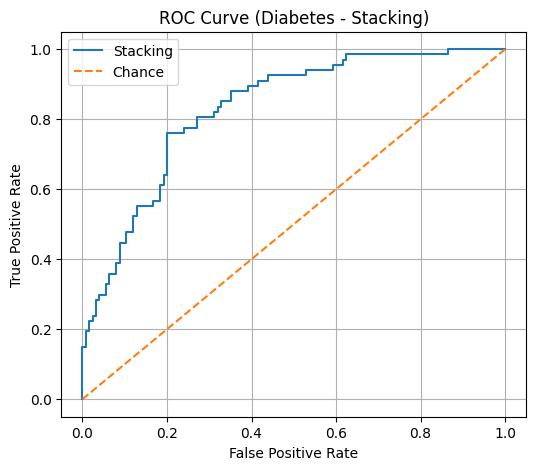

In [8]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, proba_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="Stacking")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Diabetes - Stacking)")
plt.legend()
plt.grid(True)
plt.show()



### ۶.۲ پیاده‌سازی استکینگ «از صفر» با پیش‌بینی‌های OOF

`sklearn` ساخت OOF را به‌صورت داخلی انجام می‌دهد. فهم دقیق این مرحله مهم است چون:
- روشن می‌کند **چرا** استکینگ کمک می‌کند،
- از باگ‌های ظریفِ لیکیج جلوگیری می‌کند،
- امکان ساخت متا-ویژگی‌های سفارشی را می‌دهد (مثلاً احتمال‌ها + margin + عدم‌قطعیت).

در این بخش احتمال‌های OOF هر مدل پایه را با `cross_val_predict` می‌سازیم و سپس روی این متا-ویژگی‌ها یک متا-یادگیرنده آموزش می‌دهیم.


In [9]:
# Build OOF predictions manually for base learners (train set only)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Z_train = []
Z_test = []

for name, model in base_learners:
    # OOF predicted probabilities for class 1
    oof_proba = cross_val_predict(
        model, X_train, y_train,
        cv=skf, method="predict_proba", n_jobs=None
    )[:, 1]
    Z_train.append(oof_proba.reshape(-1, 1))

    # Fit on full training and predict on test
    model.fit(X_train, y_train)
    test_proba = model.predict_proba(X_test)[:, 1]
    Z_test.append(test_proba.reshape(-1, 1))

Z_train = np.hstack(Z_train)  # shape (n_train, J)
Z_test  = np.hstack(Z_test)   # shape (n_test, J)

print("Meta-feature shapes:", Z_train.shape, Z_test.shape)
print("First 5 rows of Z_train:")
print(Z_train[:5])

# Meta-learner
meta = LogisticRegression(max_iter=600, random_state=RANDOM_STATE)
meta.fit(Z_train, y_train)

proba_meta = meta.predict_proba(Z_test)[:, 1]
pred_meta = (proba_meta >= 0.5).astype(int)

print("\nManual stacking results:")
print(f"Accuracy: {accuracy_score(y_test, pred_meta):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, proba_meta):.4f}")
print(f"LogLoss : {log_loss(y_test, proba_meta):.4f}")


Meta-feature shapes: (576, 5) (192, 5)
First 5 rows of Z_train:
[[0.27717373 0.0975     0.16298302 0.18170234 0.06666667]
 [0.30465889 0.4075     0.61918225 0.37966589 0.4       ]
 [0.18587807 0.3075     0.3415301  0.21477745 0.33333333]
 [0.08036059 0.465      0.29562274 0.46417497 0.46666667]
 [0.23702708 0.175      0.22118615 0.19363735 0.13333333]]

Manual stacking results:
Accuracy: 0.7448
ROC-AUC : 0.8300
LogLoss : 0.4946



## ۷. استکینگ چندکلاسه (Iris)

ایریس یک دیتاست کلاسیک چندکلاسه با ۳ کلاس است. استکینگ را با ویژگی‌های زیر می‌سازیم:
- مدل‌های پایه خروجی `predict_proba` با شکل $(n, C)$ می‌دهند،
- متا-یادگیرنده یک Logistic Regression چندکلاسه است.

در استکینگ چندکلاسه معمولاً متا-ویژگی‌ها با الحاق احتمال‌های هر کلاس برای هر مدل ساخته می‌شوند:
$$
z_i = [p_1(y=1|x_i),\dots,p_1(y=C|x_i),\ p_2(y=1|x_i),\dots,p_J(y=C|x_i)].
$$

پس در مجموع $J\cdot C$ متا-ویژگی خواهیم داشت.


In [10]:
# Iris multiclass stacking
target_col = "classification"
X = df_iris.drop(columns=[target_col])
y = df_iris[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

numeric_features = X.columns.tolist()
preprocess_num = ColumnTransformer(
    transformers=[("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features)],
    remainder="drop"
)

base_learners_iris = [
    ("lr", Pipeline([("preprocess", preprocess_num),
                     ("model", LogisticRegression(max_iter=600, random_state=RANDOM_STATE))])),
    ("rf", Pipeline([("preprocess", preprocess_num),
                     ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))])),
    ("gb", Pipeline([("preprocess", preprocess_num),
                     ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))])),
    ("svc", Pipeline([("preprocess", preprocess_num),
                      ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))])),
    ("knn", Pipeline([("preprocess", preprocess_num),
                      ("model", KNeighborsClassifier(n_neighbors=11))]))
]

meta_iris = LogisticRegression(max_iter=800, random_state=RANDOM_STATE)

stack_iris = StackingClassifier(
    estimators=base_learners_iris,
    final_estimator=meta_iris,
    stack_method="predict_proba",
    cv=5
)

stack_iris.fit(X_train, y_train)
pred = stack_iris.predict(X_test)
proba = stack_iris.predict_proba(X_test)

print("Multiclass stacking (Iris)")
print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"LogLoss : {log_loss(y_test, proba):.4f}")
print()
print(classification_report(y_test, pred))


Multiclass stacking (Iris)
Accuracy: 0.9474
LogLoss : 0.1343

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.92      0.92      0.92        13
 Iris-virginica       0.92      0.92      0.92        13

       accuracy                           0.95        38
      macro avg       0.95      0.95      0.95        38
   weighted avg       0.95      0.95      0.95        38




## ۸. استکینگ با ویژگی‌های مختلط (Drug200)

دیتاست `drug200.csv` هم ویژگی‌های عددی دارد و هم categorical:

- عددی: `Age`, `Na_to_K`
- categorical: `Sex`, `BP`, `Cholesterol`
- هدف: `Drug` (چندکلاسه)

این بخش مهم است، چون استکینگ باید با **پایپ‌لاین‌ها** ساخته شود تا پیش‌پردازش باعث لیکیج نشود:
- انکودرها و ایمپیوتِرها باید فقط روی فولدهای آموزش fit شوند،
- قرار دادن `ColumnTransformer` داخل پایپ‌لاین تضمین می‌کند CV درست انجام شود.


In [11]:
# Drug200 stacking with preprocessing for mixed types
target_col = "Drug"
X = df_drug.drop(columns=[target_col])
y = df_drug[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

numeric_features = ["Age", "Na_to_K"]
categorical_features = ["Sex", "BP", "Cholesterol"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

base_learners_drug = [
    ("lr", Pipeline([("preprocess", preprocess),
                     ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])),
    ("rf", Pipeline([("preprocess", preprocess),
                     ("model", RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE))])),
    ("gb", Pipeline([("preprocess", preprocess),
                     ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))])),
    ("knn", Pipeline([("preprocess", preprocess),
                      ("model", KNeighborsClassifier(n_neighbors=17))]))
]

meta_drug = LogisticRegression(max_iter=1200, random_state=RANDOM_STATE)

stack_drug = StackingClassifier(
    estimators=base_learners_drug,
    final_estimator=meta_drug,
    stack_method="predict_proba",
    cv=5
)

stack_drug.fit(X_train, y_train)
pred = stack_drug.predict(X_test)
proba = stack_drug.predict_proba(X_test)

print("Stacking (Drug200)")
print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"LogLoss : {log_loss(y_test, proba):.4f}")


Stacking (Drug200)
Accuracy: 0.9800
LogLoss : 0.1197



## ۹. استکینگ برای رگرسیون (Diamonds)

حالا به رگرسیون می‌رویم. دیتاست `diamonds.csv` شامل:
- ستون‌های عددی: `carat`, `depth`, `table`, `x`, `y`, `z`, ...
- ستون‌های categorical: `cut`, `color`, `clarity`
- هدف: `price`

مراحل:
1. پیش‌پردازش با one-hot برای categoricalها.
2. مقایسهٔ رگرسورهای پایه (Ridge، RandomForestRegressor، GradientBoostingRegressor، SVR، kNN regressor).
3. استکینگ با متا-یادگیرندهٔ ریدج.
4. ارزیابی با RMSE و $R^2$.

چون `diamonds.csv` ممکن است بزرگ باشد، برای سرعت می‌توانیم **زیرنمونه‌گیری** کنیم (بدون تغییر منطق درس).


In [12]:
# Diamonds regression stacking (with optional subsample)
df = df_diamonds.copy()

# Optional subsampling for faster runtime (set to None to use full dataset)
subsample_n = 15000
if subsample_n is not None and len(df) > subsample_n:
    df = df.sample(subsample_n, random_state=RANDOM_STATE)

target_col = "price"
X = df.drop(columns=[target_col])
y = df[target_col].astype(float)

# Identify feature types
categorical_features = [c for c in X.columns if X[c].dtype == "object"]
numeric_features = [c for c in X.columns if X[c].dtype != "object"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

base_regressors = [
    ("ridge", Pipeline([("preprocess", preprocess), ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))])),
    ("rf",    Pipeline([("preprocess", preprocess), ("model", RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE, n_jobs=None))])),
    ("gbr",   Pipeline([("preprocess", preprocess), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])),
    ("svr",   Pipeline([("preprocess", preprocess), ("model", SVR(C=20.0, gamma="scale"))])),
    ("knn",   Pipeline([("preprocess", preprocess), ("model", KNeighborsRegressor(n_neighbors=25))])),
]

meta_reg = Ridge(alpha=1.0, random_state=RANDOM_STATE)

stack_reg = StackingRegressor(
    estimators=base_regressors,
    final_estimator=meta_reg,
    passthrough=False,
    cv=5
)

stack_reg.fit(X_train, y_train)
pred = stack_reg.predict(X_test)

print("Stacking (Diamonds regression)")
print(f"RMSE: {rmse(y_test, pred):.2f}")
print(f"R^2 : {r2_score(y_test, pred):.4f}")


Stacking (Diamonds regression)
RMSE: 65.96
R^2 : 0.9997


In [13]:
# Compare base regressors
rows = []
for name, model in base_regressors:
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    rows.append({
        "model": name,
        "rmse": rmse(y_test, p),
        "r2": r2_score(y_test, p)
    })

df_reg = pd.DataFrame(rows).sort_values("rmse")
display(df_reg)

df_reg2 = pd.concat([df_reg, pd.DataFrame([{
    "model": "stacking",
    "rmse": rmse(y_test, pred),
    "r2": r2_score(y_test, pred)
}])], ignore_index=True).sort_values("rmse")

display(df_reg2)


,model,rmse,r2
1,rf,58.043410,0.999785
2,gbr,225.902118,0.996747
4,knn,865.215575,0.952283
0,ridge,1159.638800,0.914283
3,svr,1642.966743,0.827940


,model,rmse,r2
0,rf,58.043410,0.999785
5,stacking,65.959052,0.999723
1,gbr,225.902118,0.996747
2,knn,865.215575,0.952283
3,ridge,1159.638800,0.914283
4,svr,1642.966743,0.827940


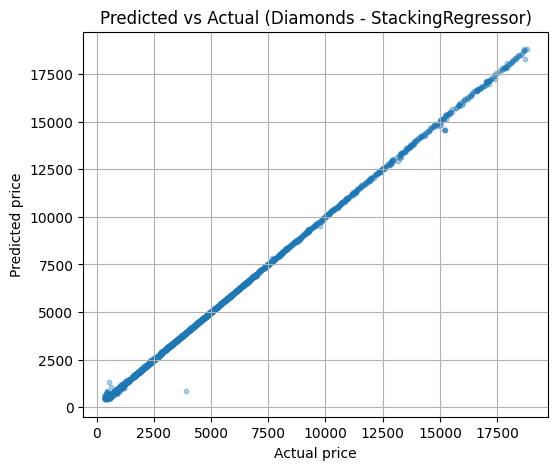

In [14]:
# Predicted vs actual scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred, alpha=0.35, s=10)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Predicted vs Actual (Diamonds - StackingRegressor)")
plt.grid(True)
plt.show()



## ۱۰. بلِندینگ (متا-یادگیرندهٔ Holdout) با House Prices

بلِندینگ به جای ساخت OOF با CV، از یک holdout برای متا-آموزش استفاده می‌کند. پروتکل معمول:
1. دادهٔ آموزشی را به **base-train** و **blend** تقسیم کنید.
2. مدل‌های پایه را روی base-train آموزش دهید.
3. روی blend پیش‌بینی بگیرید تا $Z_{\text{blend}}$ ساخته شود.
4. متا-یادگیرنده را روی $(Z_{\text{blend}}, y_{\text{blend}})$ آموزش دهید.
5. برای آزمون: پیش‌بینی‌های پایه $\rightarrow$ متا-یادگیرنده.

مبادله:
- سریع‌تر از استکینگ است، اما از دادهٔ کمتری برای آموزش مدل‌های پایه و متا استفاده می‌کند.


In [15]:
# House prices blending example
df = df_house.copy()
target_col = "Price"
X = df.drop(columns=[target_col])
y = df[target_col].astype(float)

# Identify types
categorical_features = [c for c in X.columns if X[c].dtype == "object"]
numeric_features = [c for c in X.columns if X[c].dtype != "object"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features)
    ]
)

# Outer split for evaluation
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

# Split train into base-train and blend holdout
X_base, X_blend, y_base, y_blend = train_test_split(
    X_train_full, y_train_full, test_size=0.30, random_state=RANDOM_STATE
)

base_models = [
    ("ridge", Pipeline([("preprocess", preprocess), ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))])),
    ("rf",    Pipeline([("preprocess", preprocess), ("model", RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE))])),
    ("gbr",   Pipeline([("preprocess", preprocess), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])),
    ("knn",   Pipeline([("preprocess", preprocess), ("model", KNeighborsRegressor(n_neighbors=9))])),
]

# Train base models on base set and collect blend predictions
Z_blend = []
Z_test = []
for name, model in base_models:
    model.fit(X_base, y_base)
    Z_blend.append(model.predict(X_blend).reshape(-1, 1))
    Z_test.append(model.predict(X_test).reshape(-1, 1))

Z_blend = np.hstack(Z_blend)
Z_test = np.hstack(Z_test)

meta = Ridge(alpha=1.0, random_state=RANDOM_STATE)
meta.fit(Z_blend, y_blend)

pred_blend = meta.predict(Z_test)

print("Blending (House Prices)")
print(f"RMSE: {rmse(y_test, pred_blend):.2f}")
print(f"R^2 : {r2_score(y_test, pred_blend):.4f}")


Blending (House Prices)
RMSE: 10974.88
R^2 : 0.8035



## ۱۱. مباحث پیشرفته و دام‌ها (Pitfalls)

### ۱۱.۱ الگوهای رایج لیکیج (اشتباهات متداول)
1. **پیش‌بینی‌های درون‌نمونه‌ای مدل پایه** برای آموزش متا-یادگیرنده (اشتباه کلاسیک).
2. fit شدن پیش‌پردازش روی کل داده قبل از CV (مثل اسکیلینگ/ایمپیوت/انکودینگ).
3. Target encoding که با کل داده fit شود (باید فولد-آگاه باشد).
4. سری‌زمانی: CV تصادفی آینده و گذشته را مخلوط می‌کند (باید split زمان‌محور استفاده کنید).

### ۱۱.۲ هم‌بستگی شدید مدل‌های پایه و ناپایداری وزن‌ها
اگر پیش‌بینی‌های پایه هم‌بستگی زیاد داشته باشند، $Z^\top Z$ بدشرط می‌شود:
- وزن‌ها می‌توانند بزرگ شوند و همدیگر را خنثی کنند،
- متا-یادگیرنده ناپایدار می‌شود.

راهکارها:
- منظم‌سازی (ridge / L2)،
- کاهش تعداد مدل‌ها و افزایش تنوع،
- قیود تفسیرپذیر (وزن‌های نامنفی)،
- هموارسازی متا-ویژگی‌ها و کالیبراسیون.

### ۱۱.۳ بلِندینگ با وزن‌های مقید (اختیاری)
گاهی برای تفسیرپذیری می‌خواهید $w_j \ge 0$ و $\sum_j w_j = 1$:
$$
\hat{y} = \sum_{j=1}^J w_j m_j(x).
$$
این یک بهینه‌سازی مقید است. یک روش عددی ساده برای رگرسیون را نشان می‌دهیم (در صورت وجود SciPy).


In [16]:
# Optional: constrained weights for regression blending using scipy.optimize
# This section is optional; it demonstrates the idea, not a strict requirement for stacking/blending.
try:
    from scipy.optimize import minimize
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

print("SciPy available:", SCIPY_AVAILABLE)

if SCIPY_AVAILABLE:
    # We'll reuse the blending setup (house prices) with Z_test, Z_blend and y_blend, y_test
    # Optimize weights on blend set to minimize RMSE, with constraints w>=0 and sum(w)=1.
    Z = Z_blend
    yb = y_blend.values if hasattr(y_blend, "values") else y_blend

    J = Z.shape[1]
    w0 = np.ones(J) / J

    def objective(w):
        pred = Z @ w
        return rmse(yb, pred)

    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    bounds = [(0.0, 1.0) for _ in range(J)]

    res = minimize(objective, w0, bounds=bounds, constraints=constraints, method="SLSQP")
    w_opt = res.x

    print("Optimal weights:", w_opt)
    print("Sum weights:", w_opt.sum())

    pred_test_w = Z_test @ w_opt
    print("\nConstrained blending (House Prices)")
    print(f"RMSE: {rmse(y_test, pred_test_w):.2f}")
    print(f"R^2 : {r2_score(y_test, pred_test_w):.4f}")


SciPy available: True
Optimal weights: [1.00000000e+00 0.00000000e+00 0.00000000e+00 9.27624934e-08]
Sum weights: 1.0000000927624935

Constrained blending (House Prices)
RMSE: 9938.48
R^2 : 0.8389



## ۱۲. جمع‌بندی و نکات کلیدی

- **استکینگ** یک متا-یادگیرنده را روی **پیش‌بینی‌های OOF** آموزش می‌دهد. معمولاً از بلِندینگ قابل‌اعتمادتر و از نظر استفاده از داده کاراتر است—اگر درست پیاده‌سازی شود.
- **بلِندینگ** متا-یادگیرنده را روی یک holdout ثابت آموزش می‌دهد. ساده‌تر و ارزان‌تر است اما از داده کمتر استفاده می‌کند.
- بزرگ‌ترین ریسک **لیکیج** است: متا-ویژگی‌ها را مثل ویژگی‌های عادی بسازید—بدون دسترسی به هدف همان نمونه.
- از **پایپ‌لاین**‌ها و `ColumnTransformer` استفاده کنید تا پیش‌پردازش فولد-ایمن باشد.
- متا-یادگیرنده را منظم‌سازی کنید (به‌خصوص وقتی مدل‌های پایه هم‌بستگی دارند).

### تمرین‌های پیشنهادی
1. روی `Wine_Quality.csv` کیفیت را دودویی کنید (مثلاً $\ge 7$) و یک stacking classifier بسازید.
2. `passthrough=True` را امتحان کنید و اثر آن را با/بدون منظم‌سازی قوی مشاهده کنید.
3. متا-یادگیرندهٔ لجستیک را با یک مدل درختی کوچک جایگزین کنید و کالیبراسیون/لاگ‌لاس را مقایسه کنید.

### منابع پیشنهادی (مفهومی)
- “Stacked Generalization” (Wolpert) و کارهای نظری مرتبط با ensembles.
- مستندات عملی: `StackingClassifier` و `StackingRegressor` در scikit-learn.
